# Notebook 02 — Population Genetics
## Allele Frequencies · Heterozygosity · Population Structure

---


This notebook characterises the genetic diversity of our gorilla population:
- Allele frequency spectra per locus
- Expected and observed heterozygosity
- Inbreeding coefficient F_IS
- Population differentiation (F_ST) between social groups
- Genetic diversity in context of conservation concerns

---

In [1]:
# Cell 1 — Imports
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu

ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

from utils import (
    LOCUS_NAMES, COLOUR_MAP, set_plot_style,
    save_figure, get_data_dir, get_output_dir
)
from parentage_functions import (
    build_freq_table, hwe_exact_chi2, pic_per_locus
)

set_plot_style()
DATA_RAW  = get_data_dir('raw')
DATA_PROC = get_data_dir('processed')
FIG_DIR   = get_output_dir('figures')
TAB_DIR   = get_output_dir('tables')

# Load QC-filtered data
geno_df  = pd.read_csv(DATA_PROC / 'genotypes_qc.csv')
ind_df   = pd.read_csv(DATA_PROC / 'individuals_qc.csv')
groups_df= pd.read_csv(DATA_RAW  / 'groups.csv')

with open(DATA_PROC / 'qc_loci.txt') as f:
    QC_LOCI = [l.strip() for l in f.readlines() if l.strip()]

print(f'Loaded {len(ind_df)} individuals | {len(QC_LOCI)} QC-passed loci')

Loaded 63 individuals | 15 QC-passed loci


In [2]:
# Cell 2 — Compute allele frequency table and diversity statistics
freq_table = build_freq_table(geno_df, QC_LOCI)

stats_rows = []
for locus in QC_LOCI:
    hwe = hwe_exact_chi2(geno_df, locus)
    pic = pic_per_locus(freq_table, locus)
    f   = freq_table.get(locus, {})
    stats_rows.append({
        'locus':      locus,
        'n_alleles':  hwe['n_alleles'],
        'Ho':         hwe['Ho'],
        'He':         hwe['He'],
        'F_is':       hwe['F_is'],
        'PIC':        round(pic, 4),
        'p_HWE':      hwe['p_value'],
        'max_allele_freq': round(max(f.values()) if f else np.nan, 4),
    })

stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False))
stats_df.to_csv(TAB_DIR / 'locus_diversity_stats.csv', index=False)

print(f'\nMean He: {stats_df["He"].mean():.4f} ± {stats_df["He"].std():.4f}')
print(f'Mean Ho: {stats_df["Ho"].mean():.4f} ± {stats_df["Ho"].std():.4f}')
print(f'Mean F_IS: {stats_df["F_is"].mean():.4f} (0=no inbreeding, >0=excess homozygotes)')

  locus  n_alleles     Ho     He   F_is    PIC  p_HWE  max_allele_freq
D2S1338         13 0.7119 0.8862 0.1968 0.8760 0.0000           0.2034
D3S1358          7 0.6500 0.8249 0.2120 0.8012 0.0004           0.2417
 D5S818          9 0.7895 0.8270 0.0454 0.8059 0.4535           0.2807
 D7S820          9 0.7759 0.8291 0.0642 0.8087 0.2817           0.2845
D8S1179          9 0.7547 0.8491 0.1111 0.8312 0.0551           0.2264
D13S317          7 0.6774 0.8037 0.1571 0.7784 0.0123           0.3226
D16S539          7 0.7581 0.8258 0.0821 0.8023 0.1594           0.2419
 D18S51         11 0.7119 0.8065 0.1174 0.7906 0.0657           0.3814
D19S433          6 0.5738 0.7044 0.1854 0.6727 0.0254           0.4836
 D21S11         11 0.7288 0.8532 0.1458 0.8367 0.0069           0.2119
    vWA          8 0.6557 0.7386 0.1122 0.7100 0.1405           0.4426
    FGA         12 0.7000 0.8750 0.2000 0.8631 0.0000           0.2250
 CSF1PO          7 0.7049 0.7734 0.0886 0.7367 0.2010           0.2705
   TPO

  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\02_allele_frequency_spectra.png


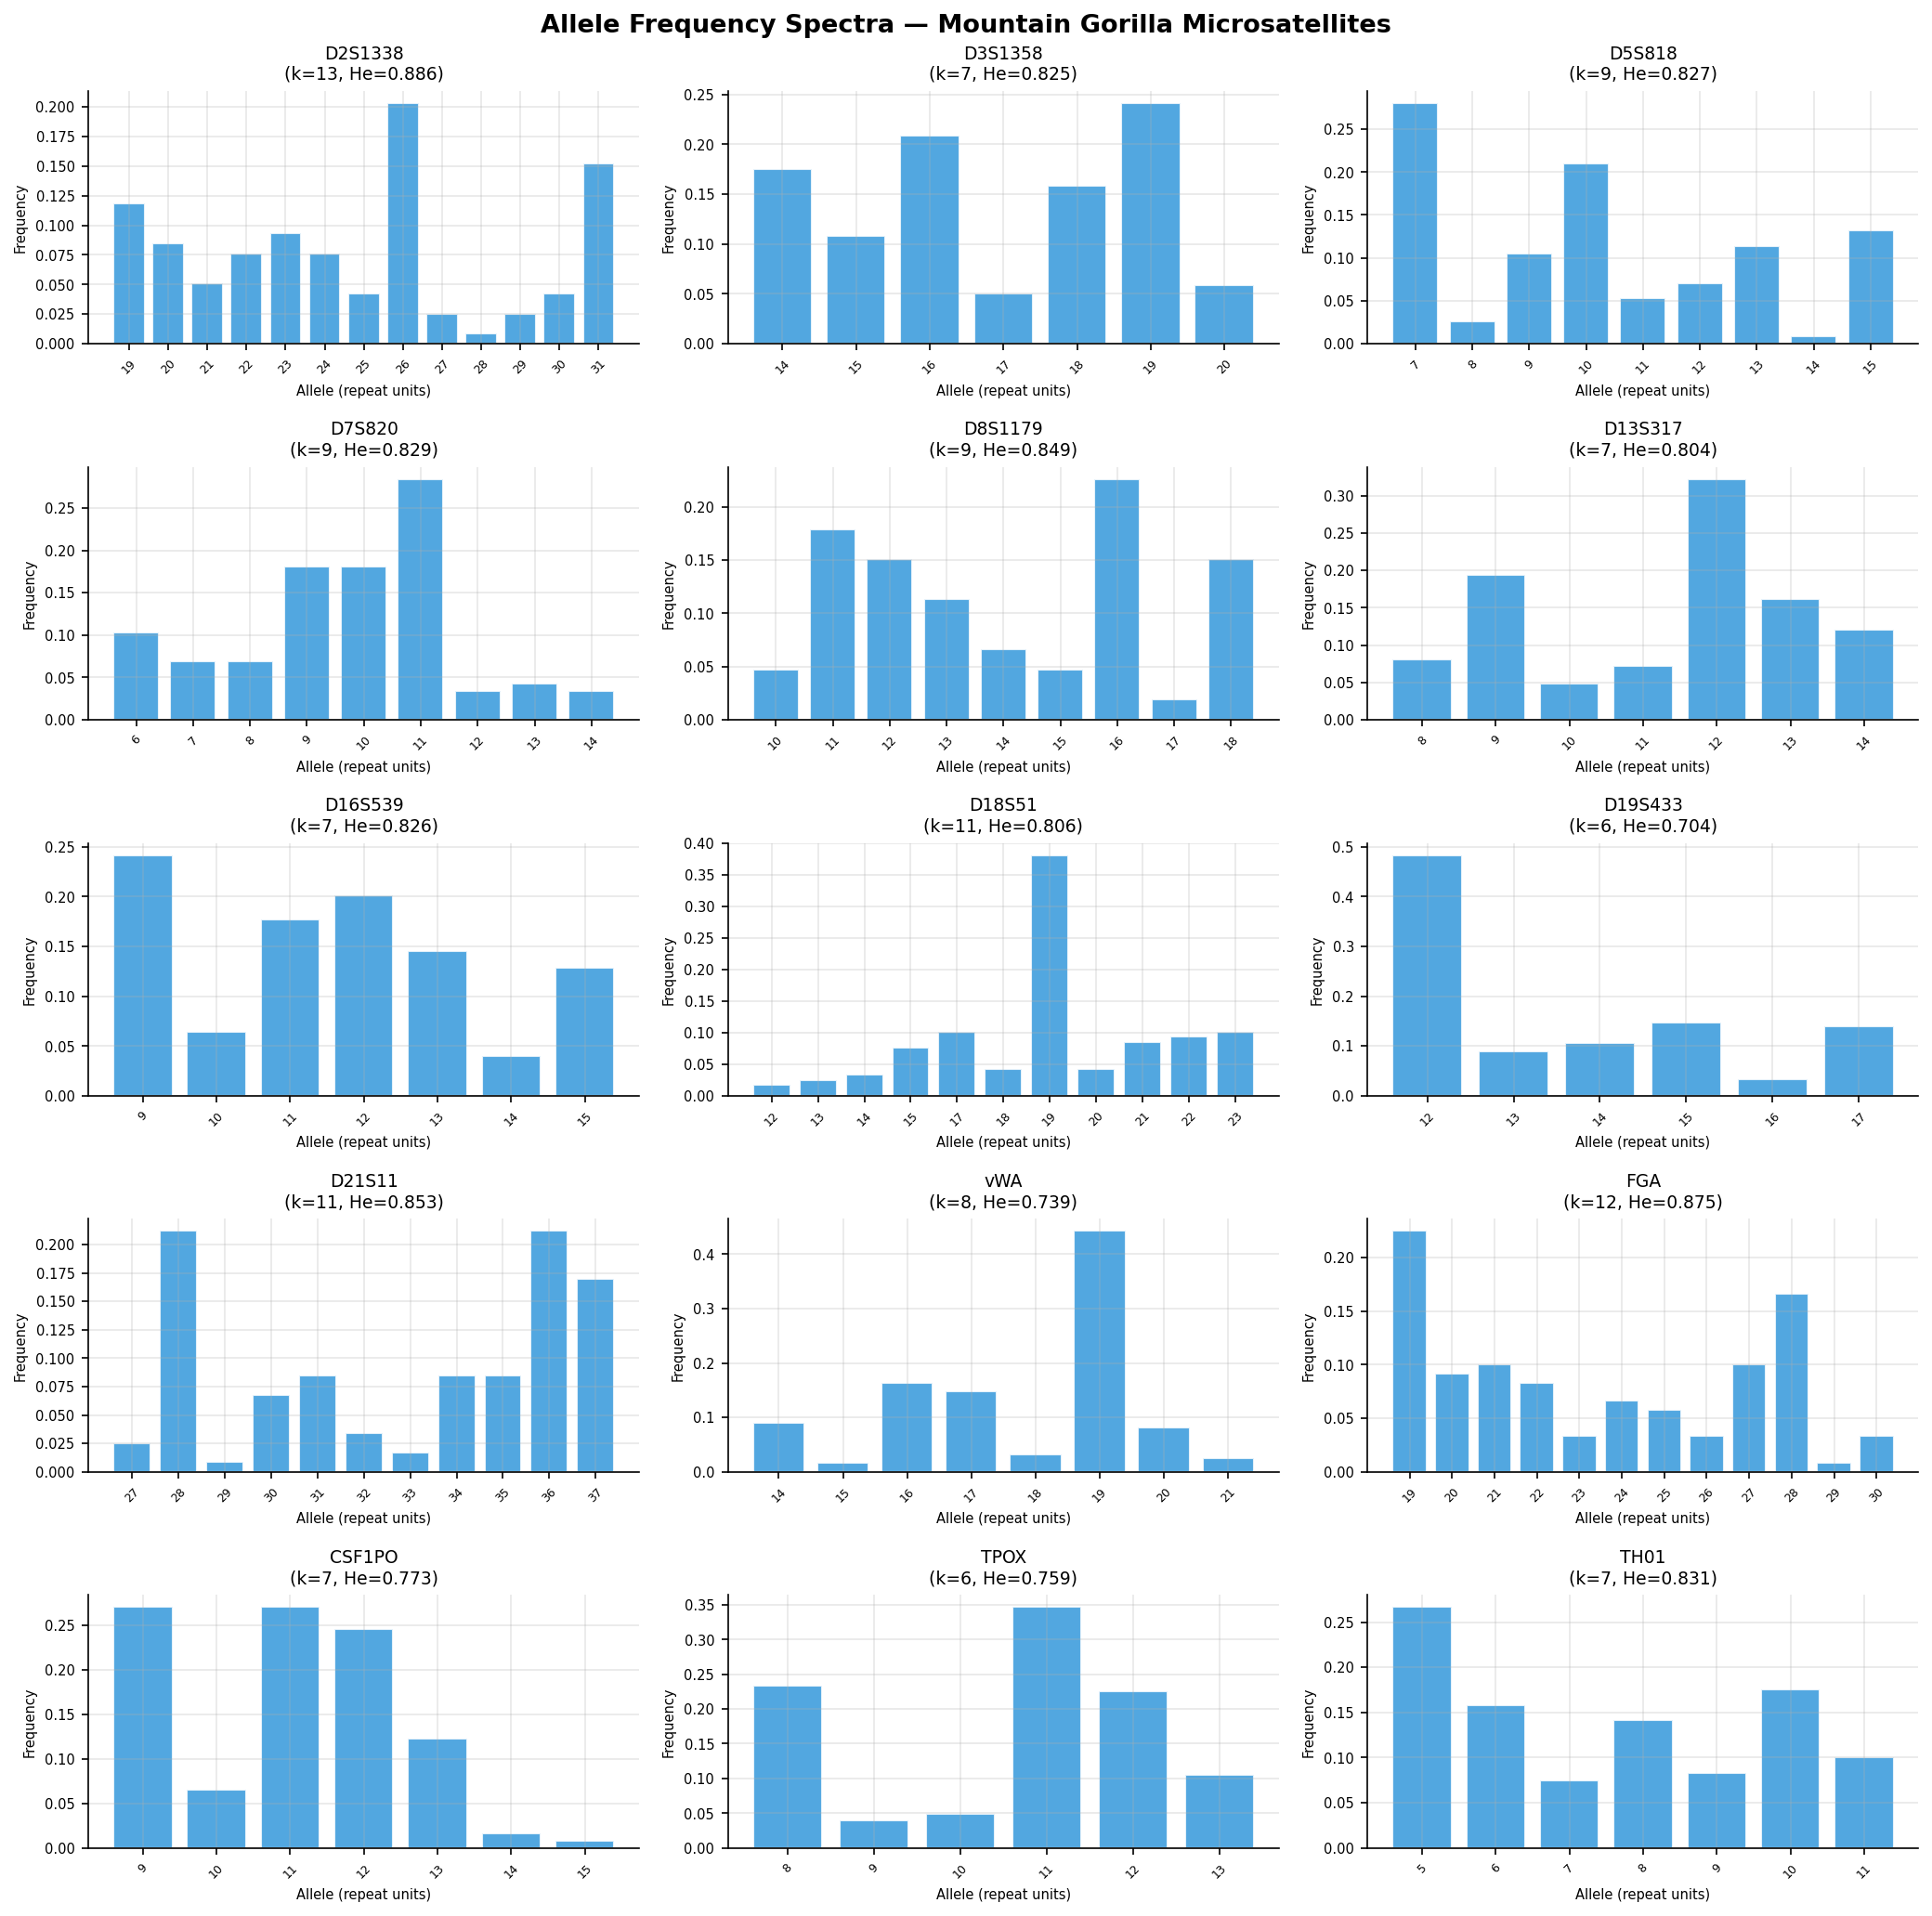

In [3]:
# Cell 3 — Allele frequency spectra (all loci)
n_loci = len(QC_LOCI)
ncols  = 3
nrows  = int(np.ceil(n_loci / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 2.8))
fig.suptitle('Allele Frequency Spectra — Mountain Gorilla Microsatellites', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, locus in enumerate(QC_LOCI):
    ax    = axes[i]
    freqs = freq_table.get(locus, {})
    if not freqs:
        ax.set_visible(False)
        continue
    alleles = sorted(freqs.keys())
    f_vals  = [freqs[a] for a in alleles]
    ax.bar([str(a) for a in alleles], f_vals,
           color='#3498DB', edgecolor='white', alpha=0.85)
    ax.set_title(f'{locus}\n(k={len(alleles)}, He={stats_df[stats_df["locus"]==locus]["He"].values[0]:.3f})',
                 fontsize=9)
    ax.set_xlabel('Allele (repeat units)', fontsize=7)
    ax.set_ylabel('Frequency', fontsize=7)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_figure(fig, '02_allele_frequency_spectra')
plt.show()

  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\02_heterozygosity.png


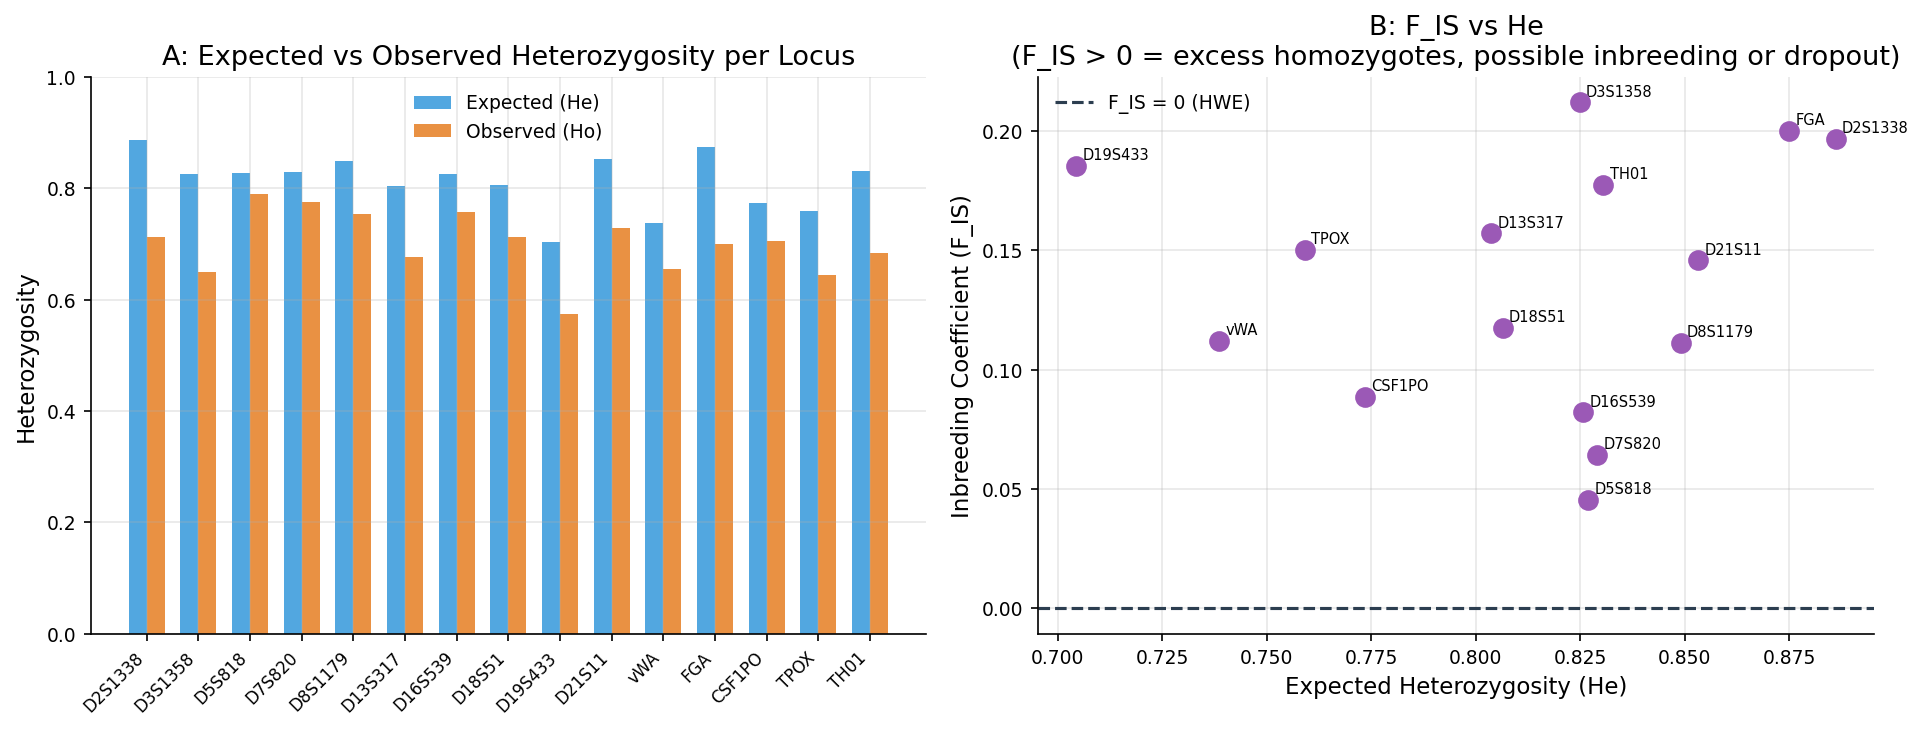

In [4]:
# Cell 4 — Heterozygosity across loci
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(QC_LOCI))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, stats_df['He'], w, label='Expected (He)', color='#3498DB', alpha=0.85)
ax.bar(x + w/2, stats_df['Ho'], w, label='Observed (Ho)', color='#E67E22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(QC_LOCI, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Heterozygosity')
ax.set_title('A: Expected vs Observed Heterozygosity per Locus')
ax.legend()
ax.set_ylim(0, 1)

ax = axes[1]
ax.scatter(stats_df['He'], stats_df['F_is'], c='#9B59B6', s=80, zorder=5)
for _, row in stats_df.iterrows():
    ax.annotate(row['locus'], (row['He'], row['F_is']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.axhline(0, color='#2C3E50', lw=1.5, ls='--', label='F_IS = 0 (HWE)')
ax.set_xlabel('Expected Heterozygosity (He)')
ax.set_ylabel('Inbreeding Coefficient (F_IS)')
ax.set_title('B: F_IS vs He\n(F_IS > 0 = excess homozygotes, possible inbreeding or dropout)')
ax.legend()

plt.tight_layout()
save_figure(fig, '02_heterozygosity')
plt.show()

In [5]:
# Cell 5 — F_ST between social groups (population differentiation)
# F_ST = (H_T - H_S) / H_T  [Nei 1977 G_ST approximation]

group_ids = ind_df['group_id'].unique()
id_to_group = ind_df.set_index('individual_id')['group_id'].to_dict()

fst_rows = []
for locus in QC_LOCI:
    col1 = f'{locus}_a1'
    col2 = f'{locus}_a2'
    
    # Total heterozygosity
    all_a = pd.concat([geno_df[col1], geno_df[col2]]).dropna().astype(int)
    all_f = all_a.value_counts(normalize=True)
    H_T   = 1.0 - float((all_f**2).sum())
    
    # Within-group heterozygosity (average across groups)
    H_S_vals = []
    for gid in group_ids:
        g_inds = ind_df[ind_df['group_id'] == gid]['individual_id']
        sub    = geno_df[geno_df['individual_id'].isin(g_inds)]
        g_a    = pd.concat([sub[col1], sub[col2]]).dropna().astype(int)
        if len(g_a) < 4:
            continue
        g_f  = g_a.value_counts(normalize=True)
        H_S_vals.append(1.0 - float((g_f**2).sum()))
    
    H_S = np.mean(H_S_vals) if H_S_vals else np.nan
    F_ST = (H_T - H_S) / H_T if H_T > 0 else np.nan
    fst_rows.append({'locus': locus, 'H_T': round(H_T,4), 'H_S': round(H_S,4), 'F_ST': round(F_ST,4)})

fst_df = pd.DataFrame(fst_rows)
print('--- F_ST per locus (Nei 1977 G_ST) ---')
print(fst_df.to_string(index=False))
print(f'\nMean F_ST: {fst_df["F_ST"].mean():.4f}')
print('Interpretation: F_ST < 0.05 = little differentiation; 0.05–0.25 = moderate')
fst_df.to_csv(TAB_DIR / 'fst_between_groups.csv', index=False)

--- F_ST per locus (Nei 1977 G_ST) ---
  locus    H_T    H_S   F_ST
D2S1338 0.8862 0.8376 0.0548
D3S1358 0.8249 0.7479 0.0933
 D5S818 0.8270 0.7468 0.0970
 D7S820 0.8291 0.7365 0.1116
D8S1179 0.8491 0.7826 0.0783
D13S317 0.8037 0.7454 0.0725
D16S539 0.8258 0.7633 0.0757
 D18S51 0.8065 0.7739 0.0404
D19S433 0.7044 0.6353 0.0980
 D21S11 0.8532 0.7816 0.0839
    vWA 0.7386 0.6746 0.0866
    FGA 0.8750 0.7961 0.0902
 CSF1PO 0.7734 0.7209 0.0679
   TPOX 0.7591 0.7029 0.0741
   TH01 0.8306 0.7470 0.1006

Mean F_ST: 0.0817
Interpretation: F_ST < 0.05 = little differentiation; 0.05–0.25 = moderate


In [6]:
# Cell 6 — Per-group heterozygosity (conservation diversity metric)
group_div_rows = []
for gid in group_ids:
    g_inds = ind_df[ind_df['group_id'] == gid]['individual_id']
    sub    = geno_df[geno_df['individual_id'].isin(g_inds)]
    if sub.empty:
        continue
    grp_freq = build_freq_table(sub, QC_LOCI)
    Ho_vals, He_vals = [], []
    for locus in QC_LOCI:
        hwe = hwe_exact_chi2(sub, locus)
        if not np.isnan(hwe['Ho']):
            Ho_vals.append(hwe['Ho'])
            He_vals.append(hwe['He'])
    grp_name = groups_df[groups_df['id']==gid]['name'].values[0]
    group_div_rows.append({
        'group_id': gid,
        'name':     grp_name,
        'n_ind':    len(g_inds),
        'mean_Ho':  round(np.mean(Ho_vals),4) if Ho_vals else np.nan,
        'mean_He':  round(np.mean(He_vals),4) if He_vals else np.nan,
    })

grp_div_df = pd.DataFrame(group_div_rows)
print('--- Per-group genetic diversity ---')
print(grp_div_df.to_string(index=False))
grp_div_df.to_csv(TAB_DIR / 'per_group_diversity.csv', index=False)

--- Per-group genetic diversity ---
group_id     name  n_ind  mean_Ho  mean_He
      G1     Susa     10   0.6585   0.7641
      G2  Amahoro     10   0.7572   0.7261
      G3  Umubano     12   0.7037   0.7664
      G4 Sabyinyo      9   0.7057   0.7298
      G5    Hirwa     13   0.6997   0.7653
      G6 Kwitonda      9   0.6667   0.7253


  Saved → c:\Users\User\Desktop\gorilla-paternity-analysis\outputs\figures\02_population_genetics_summary.png


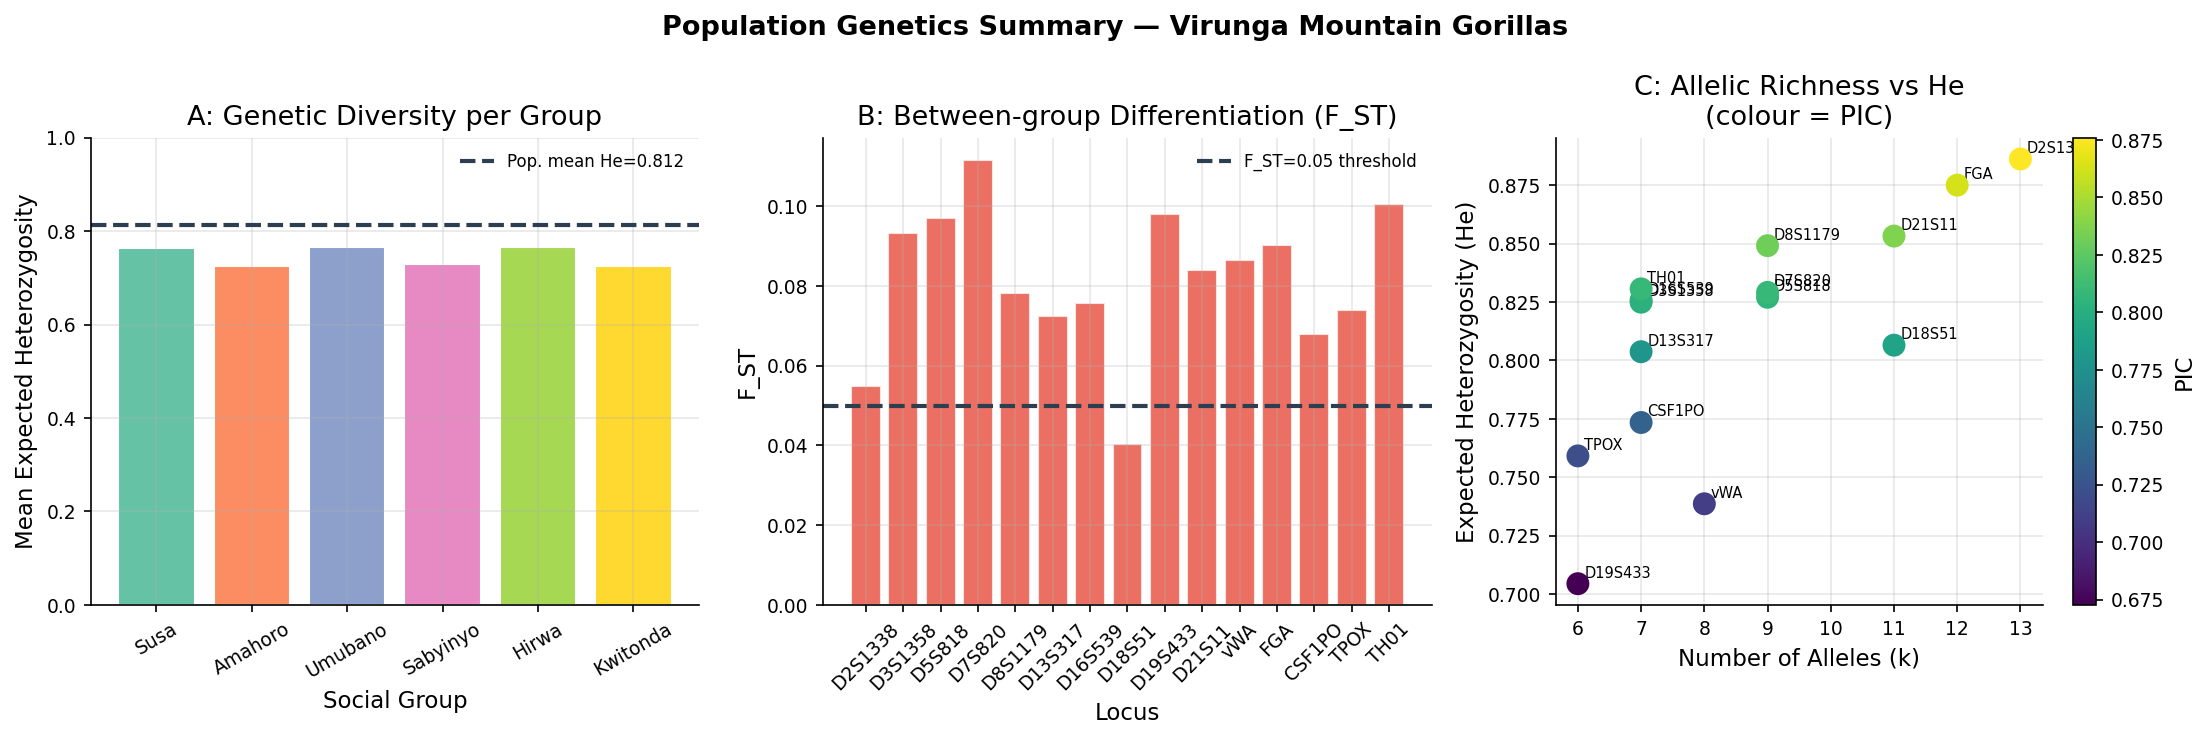

Notebook 02 complete. Proceed to 03_parentage_analysis.ipynb


In [7]:
# Cell 7 — Population genetics summary figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Population Genetics Summary — Virunga Mountain Gorillas', fontsize=13, fontweight='bold')

# A: Mean He per group
ax = axes[0]
colors = sns.color_palette('Set2', len(grp_div_df))
bars = ax.bar(grp_div_df['name'], grp_div_df['mean_He'], color=colors, edgecolor='white')
ax.axhline(stats_df['He'].mean(), ls='--', color='#2C3E50', lw=2, label=f'Pop. mean He={stats_df["He"].mean():.3f}')
ax.set_xlabel('Social Group')
ax.set_ylabel('Mean Expected Heterozygosity')
ax.set_title('A: Genetic Diversity per Group')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

# B: F_ST across loci
ax = axes[1]
ax.bar(fst_df['locus'], fst_df['F_ST'], color='#E74C3C', edgecolor='white', alpha=0.8)
ax.axhline(0.05, ls='--', color='#2C3E50', lw=2, label='F_ST=0.05 threshold')
ax.set_xlabel('Locus')
ax.set_ylabel('F_ST')
ax.set_title('B: Between-group Differentiation (F_ST)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)

# C: Allelic richness vs He
ax = axes[2]
ax.scatter(stats_df['n_alleles'], stats_df['He'], c=stats_df['PIC'],
           cmap='viridis', s=100, zorder=5)
for _, row in stats_df.iterrows():
    ax.annotate(row['locus'], (row['n_alleles'], row['He']),
                fontsize=7, xytext=(3,3), textcoords='offset points')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(stats_df['PIC'].min(), stats_df['PIC'].max()))
plt.colorbar(sm, ax=ax, label='PIC')
ax.set_xlabel('Number of Alleles (k)')
ax.set_ylabel('Expected Heterozygosity (He)')
ax.set_title('C: Allelic Richness vs He\n(colour = PIC)')

plt.tight_layout()
save_figure(fig, '02_population_genetics_summary')
plt.show()

print('Notebook 02 complete. Proceed to 03_parentage_analysis.ipynb')